# **Tutorial**: reconstructing inelastic tunneling characteristics 

Measured signals may get corrupted by various factors, such as measurement-induced uncertainties, physics-based resolution limitations and noise corruption through intrinsic and external sources. The package **cssr** (compressive sensing-based super-resolver) is intended to tackle physics-based resolution limitations and noise simultaneously. Specifically, the package intends to recover signals that admit a sparse representation which have been low-pass filtered and are subject to noise corruption. 

In this tutorial, we will look at how two prominent linewidth broadening effects in scanning tunneling microscopy (STM) can be overcome through the **cssr** package. In particular, let us look at inelastic-electron-tunneling processes that leave a characteristic signature in the current-voltage curves, which are subject to thermal and instrumental linewidth broadening effects. To reconstruct the ground truth, we will assemble appropriate sensing matrices by incorporating these effects, and we will make use of the **cssr** package frame library by constructing **overcomplete dictionaries** that encode a large range of possible sparsifying basis vectors (known as atoms in the Compressed Sensing literature).

## Preliminaries:

We start by importing the package **cssr**:

In [1]:
import cssr

Next, let us import the needed packages for the plotting specifications and to construct our trial signal:

In [2]:
import scipy
import random
import numpy as np
import matplotlib.pyplot as plt

Let us also specify the font sizes for the plots that we will construct sortly after:

In [3]:
font1 = 17
font2 = 13

For convenience, we disable the warnings that appear during the plotting porcedure:

In [4]:
import warnings
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

## Setting up a trial signal that capture inelastic tunneling:

We are now ready to set up the trail signal (the **second derivative** of the current-voltage curve), set up in two steps. In step 1, we construct the sparse representation of the signal, followed by applying a convolution on the sparse representation with a Lorentzian distribution (also known as a Cauchy distribution). The resulting array is called the original signal. In step 2, lowpass filters are applied on the original signal (thermal and instrumental broadening), followed by additional signal corruption through a noise term (representing a signal as measured in a real world scenario).

### Step 1:

#### **Sparse representation**:

We choose to set up a signal with 4 peaks, i.e., a 4-sparse signal, in an interval from -0.2 to 0.2 volts and a resolution of 0.005 volt:

In [5]:
x = np.arange(-0.2, 0.2, 0.005)
dim = x.shape[0]

Next, the amplitudes and the locations of these peaks are assigned. In particular, we intentionally indicate an appropriate scale of the amplitudes, while using a rescaled version throughout the tutorial for numerical stability:

In [6]:
scale = 1e-9
amps = np.array([[0.2, -0.8, 0.8, -0.2]]).T
peaks = [-0.06, -0.03, 0.03, 0.06]
indices = np.array([np.argmin(np.abs(x - peak)) for peak in peaks])

Finally, the constructed objects are used to set up the sparse trial signal $y_{\text{sparse}}(v)$. We split the sparse signal into two parts in order to assign two Lorentzian distributions with differing half-width at hald-maximas: 

In [7]:
y_sparse_set = [np.zeros((dim, 1)), np.zeros((dim, 1))]
y_sparse_set[0][indices[[0,-1]].tolist()] = amps[[0,-1]]
y_sparse_set[1][indices[[1,2]].tolist()] = amps[[1,2]]

In [8]:
y_sparse = sum(y_sparse_set)

#### **Ground truth**:

To construct the original signal $y_{\text{original}}(t)$, we choose to convolve its sparse representation with a Lorentzian distribution with a half-width at half-maximum $\gamma$ = 0.009V and $\gamma$ = 0.005V. This is achieved by first constructing a corresponding frame (known as a dictionary in the compressive sensing literature):

In [9]:
gammas = [0.009, 0.005]
csFr = cssr.Frames(x)
a0_set = [csFr.cauchy(gammas[0]), csFr.cauchy(gammas[1])]

followed by a matrix-vector product of the sparsifying matrix and the sparse representation of the signal $y_{\text{sparse}}(t)$, which represents a convolution of $y_{\text{sparse}}(t)$ and the Cauchy distribution:

In [10]:
y_original = a0_set[0].dot(y_sparse_set[0]) + a0_set[1].dot(y_sparse_set[1])

#### Visualization:

Let us take a quick look at the constructed signal:

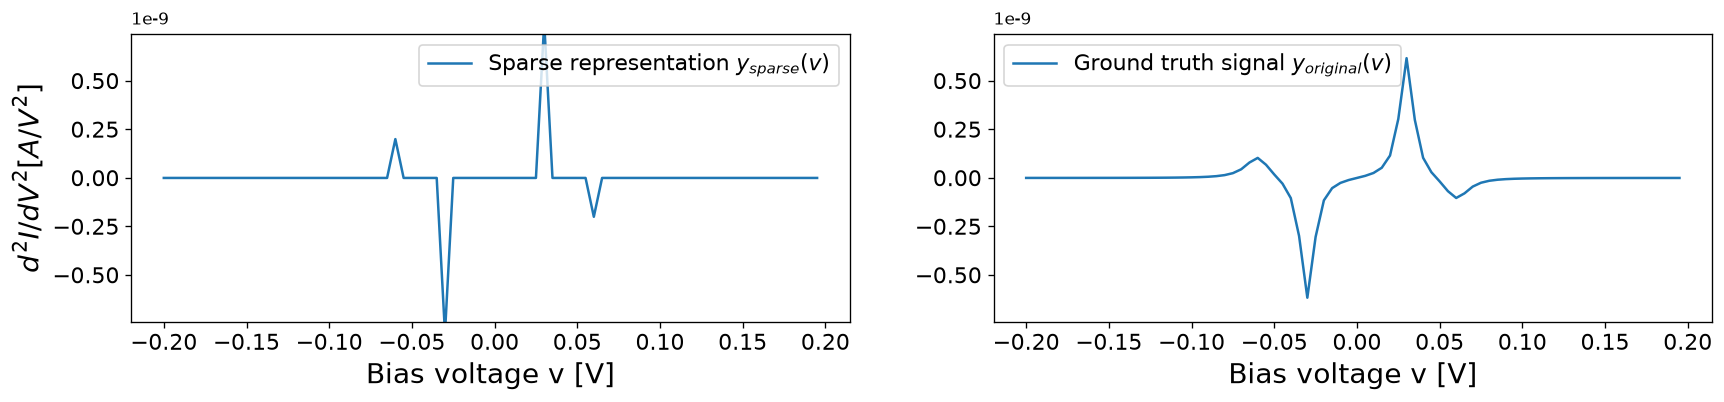

In [11]:
ylim_min = min(y_original.real)*1.2
ylim_max = max(abs(y_original))*1.2

fig1, axs1 = plt.subplots(1, 2, figsize=(17,17), dpi=120)

axs1[0].plot(x, y_sparse, label="Sparse representation $y_{sparse}(v)$")
axs1[1].plot(x, y_original, label="Ground truth signal $y_{original}(v)$")

axs1[0].set_ylabel("$d^2I/dV^2 [A/V^2]$", fontsize=font1)
axs1[0].set_xlabel("Bias voltage v [V]", fontsize=font1)
axs1[1].set_xlabel("Bias voltage v [V]", fontsize=font1)

axs1[0].legend(fontsize=font2)
axs1[1].legend(fontsize=font2)

axs1[0].set_ylim([ylim_min, ylim_max])
axs1[1].set_ylim([ylim_min, ylim_max])

axs1[0].set_box_aspect(aspect=0.4)
axs1[1].set_box_aspect(aspect=0.4)

axs1[0].tick_params(axis='both', which='major', labelsize=font2)
axs1[1].tick_params(axis='both', which='major', labelsize=font2)

axs1[0].text(0, 1.02, "1e-9", transform=axs1[0].transAxes, ha='left',va='bottom')
axs1[1].text(0, 1.02, "1e-9", transform=axs1[1].transAxes, ha='left',va='bottom')

plt.show()

### Step 2:

#### **Systemic corruption**:

We can account for system-imposed limitations on the original signal by applying the two linewidth broadening effects (giving us the signal $y_{\text{lp1}}(v)$ for the thermal broadening effect and $y_{\text{lp2i}}(v)$ for the instrumental broadening effect, where $\mathbf{i\in\{1,2,3,4\}}$) and adding a noise term (giving us the signal $y_i(t)$). In particular, we set the ambient system temperature that induces thermal broadening to **11°C**, and various modulation voltages to **0.015V**, **0.020V**, **0.025V**, and **0.030V**, which induce instrumental broadening. To apply the corresponding filters, we pass the original signal, its x-components and the chosen cutoff frequency to the **Filters** class. In addition, we specify that we intend to filter a signal through the keyword argument **filter_signal**: 

In [12]:
cutoffs = [11, 0.015, 0.020, 0.025, 0.030]

In [13]:
csFl = cssr.Filters(y_original, x, cutoffs[0], filter_signal=True)

In [14]:
y_lp1 = csFl.thermal_lowpass_filter()

and we apply the instrumental broadening with the first modulation voltage 0.015V as follows:

In [15]:
csFl.cutoff = cutoffs[1]
y_lp21 = csFl.instrumental_lowpass_filter()

Next, we reset the stateful Filters class object and construct the other signal variants under instrumental broadening:

In [16]:
csFl.reset()
csFl.thermal_lowpass_filter(return_array=False)
csFl.cutoff = cutoffs[2]
y_lp22 = csFl.instrumental_lowpass_filter()

and

In [17]:
csFl.reset()
csFl.thermal_lowpass_filter(return_array=False)
csFl.cutoff = cutoffs[3]
y_lp23 = csFl.instrumental_lowpass_filter()

as wel as

In [18]:
csFl.reset()
csFl.thermal_lowpass_filter(return_array=False)
csFl.cutoff = cutoffs[4]
y_lp24 = csFl.instrumental_lowpass_filter()

Finally, we add noise to the signals:

In [19]:
noise_level = np.sqrt(0.0002)
noise1  = np.random.randn(len(x))*noise_level
noise2  = np.random.randn(len(x))*noise_level
noise3  = np.random.randn(len(x))*noise_level
noise4  = np.random.randn(len(x))*noise_level
y1 = y_lp21 + noise1
y2 = y_lp22 + noise2
y3 = y_lp23 + noise3
y4 = y_lp24 + noise4

For convenience, let quantify the signal-to-noise ration (SNR) in decibel:

In [20]:
if noise_level:
    print("SNR y1:", 10*np.log10(np.linalg.norm(y1)/np.linalg.norm(noise1)), "dB")
    print("SNR y2:", 10*np.log10(np.linalg.norm(y2)/np.linalg.norm(noise2)), "dB")
    print("SNR y3:", 10*np.log10(np.linalg.norm(y3)/np.linalg.norm(noise3)), "dB")
    print("SNR y4:", 10*np.log10(np.linalg.norm(y4)/np.linalg.norm(noise4)), "dB")
else:
    print("SNR:", np.inf, "dB")

SNR y1: 8.031254170924058 dB
SNR y2: 8.054166012732487 dB
SNR y3: 7.806527835146637 dB
SNR y4: 6.82896577351896 dB


#### Visualization:

Let us visualize the signal together with their representations in the frequency space ($y^{\text{fft}}_{\text{original}}(\omega)$, $y^{\text{fft}}_{\text{lp1}}(\omega)$, $y^{\text{fft}}_{\text{lp2i}}(\omega)$, $y^{\text{fft}}_i(\omega)$), which we generate as follows:

In [21]:
x_fft = scipy.fft.fftshift(scipy.fft.fftfreq(x.shape[0], d=abs(x[0] - x[1])))
y_fft_original = scipy.fft.fftshift(scipy.fft.fft(y_original, axis=0))

y_fft_lp1 = scipy.fft.fftshift(scipy.fft.fft(y_lp1, axis=0))

y_fft_lp21 = scipy.fft.fftshift(scipy.fft.fft(y_lp21, axis=0))
y_fft_lp22 = scipy.fft.fftshift(scipy.fft.fft(y_lp22, axis=0))
y_fft_lp23 = scipy.fft.fftshift(scipy.fft.fft(y_lp23, axis=0))
y_fft_lp24 = scipy.fft.fftshift(scipy.fft.fft(y_lp24, axis=0))

y1_fft = scipy.fft.fftshift(scipy.fft.fft(y1, axis=0))
y2_fft = scipy.fft.fftshift(scipy.fft.fft(y2, axis=0))
y3_fft = scipy.fft.fftshift(scipy.fft.fft(y3, axis=0))
y4_fft = scipy.fft.fftshift(scipy.fft.fft(y4, axis=0))

Therefore:

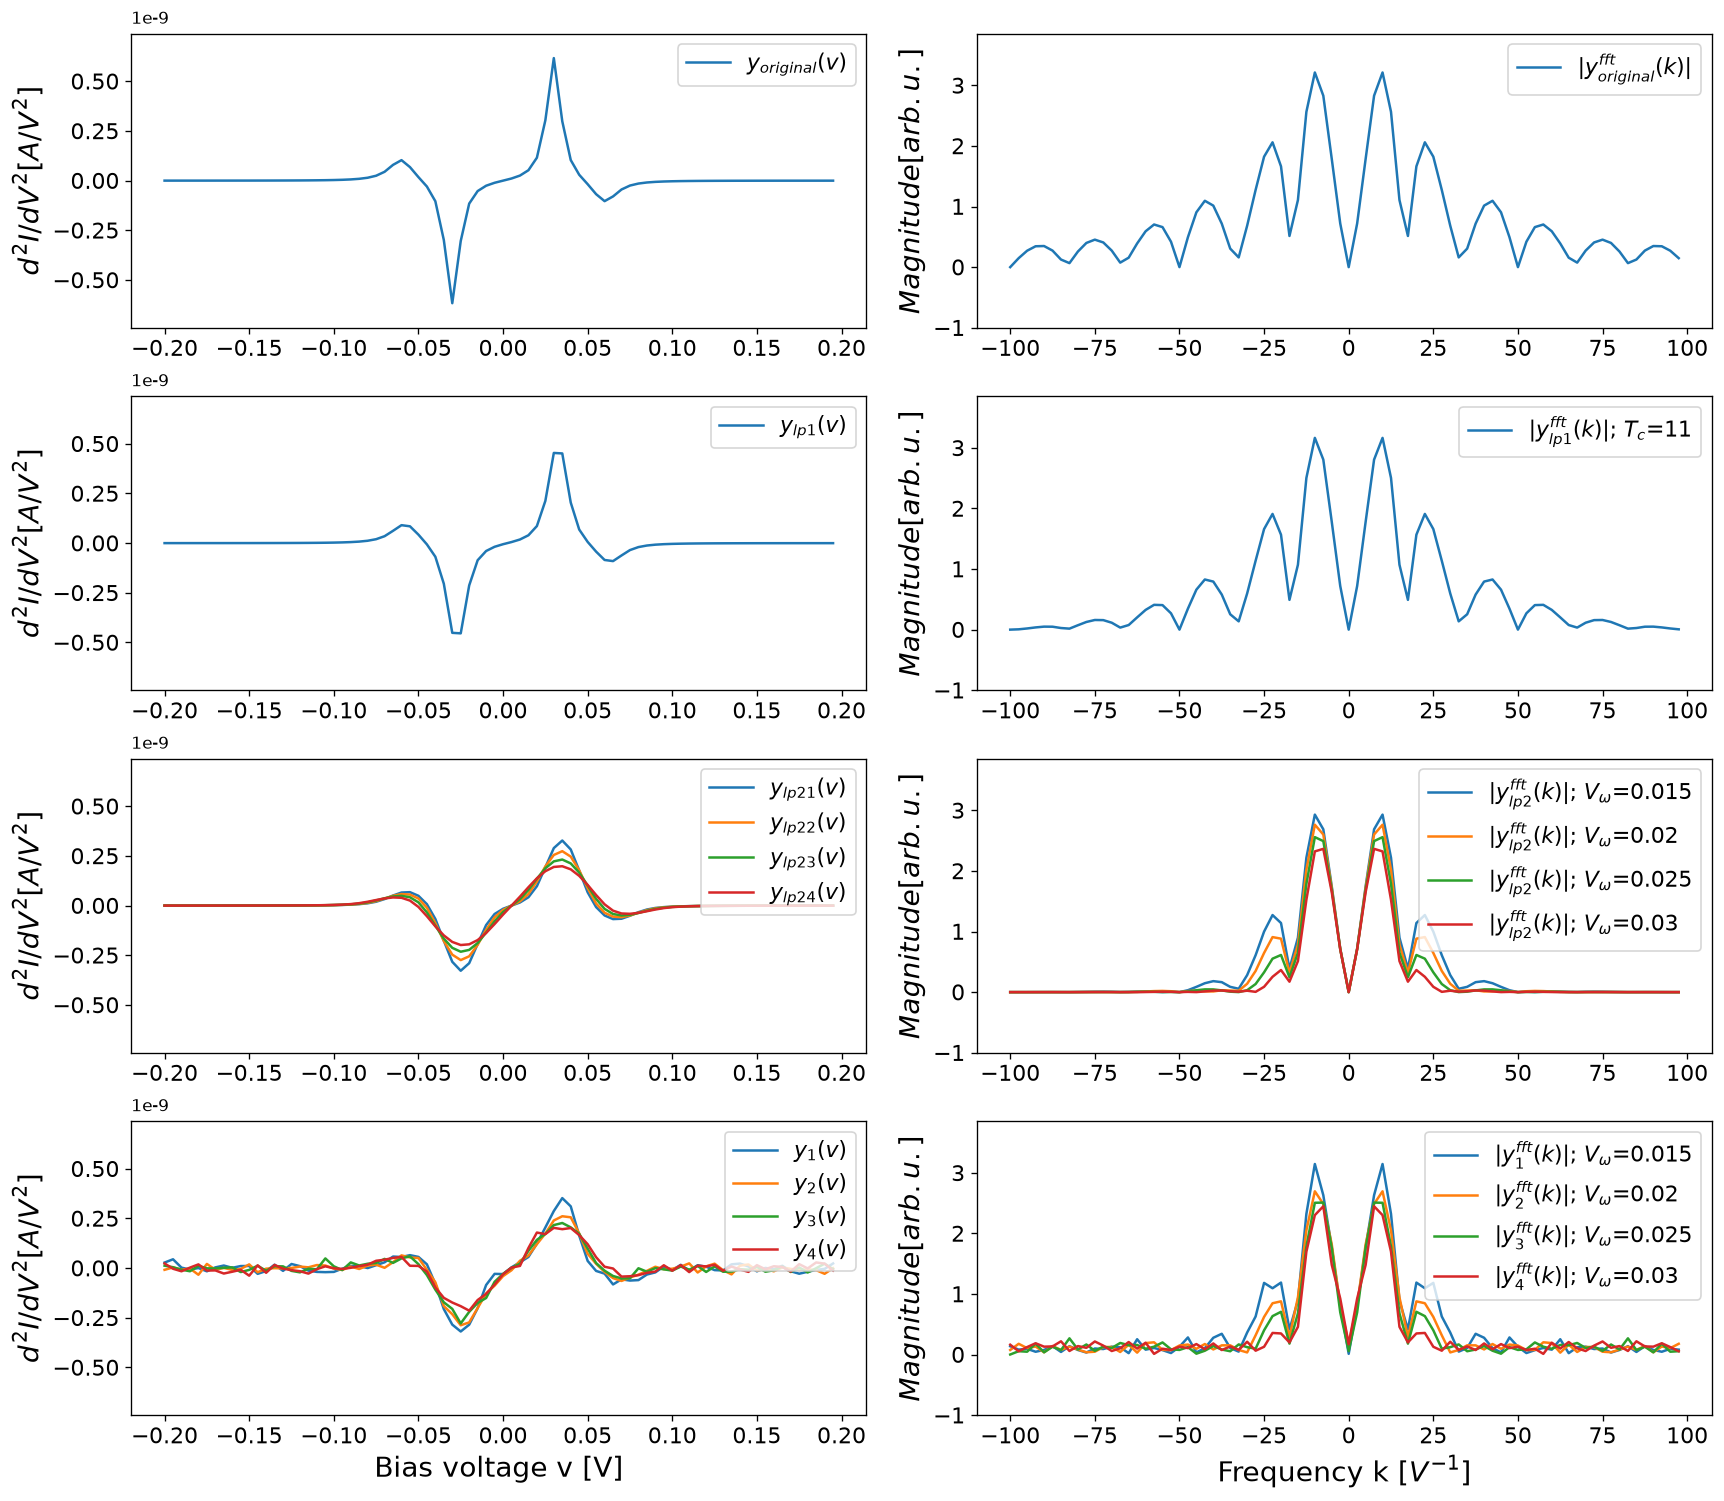

In [22]:
y_fft_lim_max  = max(abs(y_fft_original))*1.2

fig2, axs2 = plt.subplots(4, 2, figsize=(17, 17), dpi=120)

axs2[0,0].plot(x, y_original, label="$y_{original}(v)$")
axs2[0,1].plot(x_fft, abs(y_fft_original), label="$|y^{{fft}}_{{original}}(k)|$")

axs2[1,0].plot(x, y_lp1, label="$y_{lp1}(v)$")
axs2[1,1].plot(x_fft, abs(y_fft_lp1), label=f"$|y^{{fft}}_{{lp1}}(k)|$; $T_c$={cutoffs[0]}")

axs2[2,0].plot(x, y_lp21, label="$y_{lp21}(v)$")
axs2[2,0].plot(x, y_lp22, label="$y_{lp22}(v)$")
axs2[2,0].plot(x, y_lp23, label="$y_{lp23}(v)$")
axs2[2,0].plot(x, y_lp24, label="$y_{lp24}(v)$")
axs2[2,1].plot(x_fft, abs(y_fft_lp21), label=f"$|y^{{fft}}_{{lp2}}(k)|$; $V_{{\omega}}$={cutoffs[1]}")
axs2[2,1].plot(x_fft, abs(y_fft_lp22), label=f"$|y^{{fft}}_{{lp2}}(k)|$; $V_{{\omega}}$={cutoffs[2]}")
axs2[2,1].plot(x_fft, abs(y_fft_lp23), label=f"$|y^{{fft}}_{{lp2}}(k)|$; $V_{{\omega}}$={cutoffs[3]}")
axs2[2,1].plot(x_fft, abs(y_fft_lp24), label=f"$|y^{{fft}}_{{lp2}}(k)|$; $V_{{\omega}}$={cutoffs[4]}")

axs2[3,0].plot(x, y1, label="$y_1(v)$")
axs2[3,0].plot(x, y2, label="$y_2(v)$")
axs2[3,0].plot(x, y3, label="$y_3(v)$")
axs2[3,0].plot(x, y4, label="$y_4(v)$")
axs2[3,1].plot(x_fft, abs(y1_fft), label=f"$|y^{{fft}}_1(k)|$; $V_{{\omega}}$={cutoffs[1]}")
axs2[3,1].plot(x_fft, abs(y2_fft), label=f"$|y^{{fft}}_2(k)|$; $V_{{\omega}}$={cutoffs[2]}")
axs2[3,1].plot(x_fft, abs(y3_fft), label=f"$|y^{{fft}}_3(k)|$; $V_{{\omega}}$={cutoffs[3]}")
axs2[3,1].plot(x_fft, abs(y4_fft), label=f"$|y^{{fft}}_4(k)|$; $V_{{\omega}}$={cutoffs[4]}")

axs2[0,0].set_ylabel("$d^2I/dV^2 [A/V^2]$", fontsize=font1)
axs2[0,1].set_ylabel("$Magnitude [arb. u.]$", fontsize=font1)
axs2[0,0].legend(fontsize=font2)
axs2[0,1].legend(fontsize=font2)

axs2[1,0].set_ylabel("$d^2I/dV^2 [A/V^2]$", fontsize=font1)
axs2[1,1].set_ylabel("$Magnitude [arb. u.]$", fontsize=font1)
axs2[1,0].legend(fontsize=font2)
axs2[1,1].legend(fontsize=font2)

axs2[2,0].set_ylabel("$d^2I/dV^2 [A/V^2]$", fontsize=font1)
axs2[2,1].set_ylabel("$Magnitude [arb. u.]$", fontsize=font1)
axs2[2,0].legend(fontsize=font2, loc="upper right")
axs2[2,1].legend(fontsize=font2, loc="upper right")

axs2[3,0].set_xlabel("Bias voltage v [V]", fontsize=font1)
axs2[3,1].set_xlabel("Frequency k [$V^{-1}$]", fontsize=font1)
axs2[3,0].set_ylabel("$d^2I/dV^2 [A/V^2]$", fontsize=font1)
axs2[3,1].set_ylabel("$Magnitude [arb. u.]$", fontsize=font1)
axs2[3,0].legend(fontsize=font2, loc="upper right")
axs2[3,1].legend(fontsize=font2, loc="upper right")

axs2[0,1].set_ylim([-1, y_fft_lim_max ])
axs2[1,1].set_ylim([-1, y_fft_lim_max ])
axs2[2,1].set_ylim([-1, y_fft_lim_max ])
axs2[3,1].set_ylim([-1, y_fft_lim_max ])
axs2[0,0].set_ylim([ylim_min, ylim_max])
axs2[1,0].set_ylim([ylim_min, ylim_max])
axs2[2,0].set_ylim([ylim_min, ylim_max])
axs2[3,0].set_ylim([ylim_min, ylim_max])

axs2[0, 0].text(0, 1.02, "1e-9", transform=axs2[0, 0].transAxes, ha='left',va='bottom')
axs2[1, 0].text(0, 1.02, "1e-9", transform=axs2[1, 0].transAxes, ha='left',va='bottom')
axs2[2, 0].text(0, 1.02, "1e-9", transform=axs2[2, 0].transAxes, ha='left',va='bottom')
axs2[3, 0].text(0, 1.02, "1e-9", transform=axs2[3, 0].transAxes, ha='left',va='bottom')

for ax in axs2.flat:
    ax.set_box_aspect(aspect=0.4)
    ax.tick_params(axis='both', which='major', labelsize=font2)
    
fig2.subplots_adjust(hspace=-0.25, wspace=0.15)

plt.show()

## Sparse basis, low-pass filters and measurement matrices:

We are now ready to set up the central objects to reconstruct signals. It is instructive to gather the needed objects, since one would usually start a realistic reconstruction on actual data at the current point. Since our signal is composed of two Lorentzian distributions and since in a realistic scenario one may not know the precise specifications of the encoded distributions, we choose an overcomplete dictionary as the sparsifying matrix that encodes various distributions of different half-width at half-maximas:

In [23]:
a0 = cssr.Frames(x).cauchy_overcomplete(gamma_interval=[0.004,0.010], step_size=0.0005)

The information of the linewidth broadening effects is encoded by applying the same operation on the sparsifying matrix through the Filters class:

In [24]:
csFi = cssr.Filters(a0, x, cutoffs[0])

In [25]:
csFi.thermal_lowpass_filter(return_array=False)
csFi.cutoff = cutoffs[1]
a_tr1 = csFi.instrumental_lowpass_filter()

and

In [26]:
csFi.reset()
csFi.thermal_lowpass_filter(return_array=False)
csFi.cutoff = cutoffs[2]
a_tr2 = csFi.instrumental_lowpass_filter()

In [27]:
csFi.reset()
csFi.thermal_lowpass_filter(return_array=False)
csFi.cutoff = cutoffs[3]
a_tr3 = csFi.instrumental_lowpass_filter()

as well as

In [28]:
csFi.reset()
csFi.thermal_lowpass_filter(return_array=False)
csFi.cutoff = cutoffs[4]
a_tr4 = csFi.instrumental_lowpass_filter()

The compressive sensing based approach is particularly interesting since the needed measurement matrix for the reconstruction can have considerably fewer row vectors then column vectors. Let us set the number of rows to

In [29]:
number_rows = 25

Next, we can now make full use of the compressive sensing based methodology and construct an appropriate measurement matrix. We choose a so-called binary block matrix. This matrix is one of the simplest measurement matrices constructed by inserting blocks of **1s** in a staircase fashion into the diagonal entries of a zero matrix:

In [30]:
ar1 = cssr.MeasurementMatrices(a_tr1, number_rows).binary_block()
ar2 = cssr.MeasurementMatrices(a_tr2, number_rows).binary_block()
ar3 = cssr.MeasurementMatrices(a_tr3, number_rows).binary_block()
ar4 = cssr.MeasurementMatrices(a_tr4, number_rows).binary_block()

Note, matrices with binary entries, such as binary block matrices, can in principle directly be implemented into physical measurement schemes.

## **Super-resolution**:

We are finally ready to perform the compressive sensing-based super-resolution. It is instructive to reconstruct the low-pass filtered signals with and without noise:

### Reconstructing $y_\text{original}(t)$ from $y_\text{lp2i}(t)$:

To reconstruct the noiseless signals we apply one of the algorithms implemented in the **cssr** package that solve our convex problem. In particular, we choose a hybrid algorithm called MPL assisted non-local hard thresholding, which uses the **matching pursuit** and **basis pursuit denoising** for the reconstruction. The corresponding function is called nlht_lasso, and the reconstruction is performed as follows:

In [31]:
y_lp21_reconstructed, y_lp21_sparse_hat  = cssr.Superresolvers(a0, a_tr1, ar1).nlht_lasso(y_lp21)
y_lp22_reconstructed, y_lp22_sparse_hat  = cssr.Superresolvers(a0, a_tr2, ar2).nlht_lasso(y_lp22)
y_lp23_reconstructed, y_lp23_sparse_hat  = cssr.Superresolvers(a0, a_tr3, ar3).nlht_lasso(y_lp23)
y_lp24_reconstructed, y_lp24_sparse_hat  = cssr.Superresolvers(a0, a_tr4, ar4).nlht_lasso(y_lp24)

The **cssr** package returns both the reconstructed signals and their corresponding reconstructed sparse representations.

#### Visualization:

We are interested in both the reconstructed signals and its frequency space representations. Thus:

In [32]:
y_fft_lp21_hat = scipy.fft.fftshift(scipy.fft.fft(y_lp21_reconstructed, axis=0))
y_fft_lp22_hat = scipy.fft.fftshift(scipy.fft.fft(y_lp22_reconstructed, axis=0))
y_fft_lp23_hat = scipy.fft.fftshift(scipy.fft.fft(y_lp23_reconstructed, axis=0))
y_fft_lp24_hat = scipy.fft.fftshift(scipy.fft.fft(y_lp24_reconstructed, axis=0))

We can visualize and compare the reconstructed and the original signals as follows:

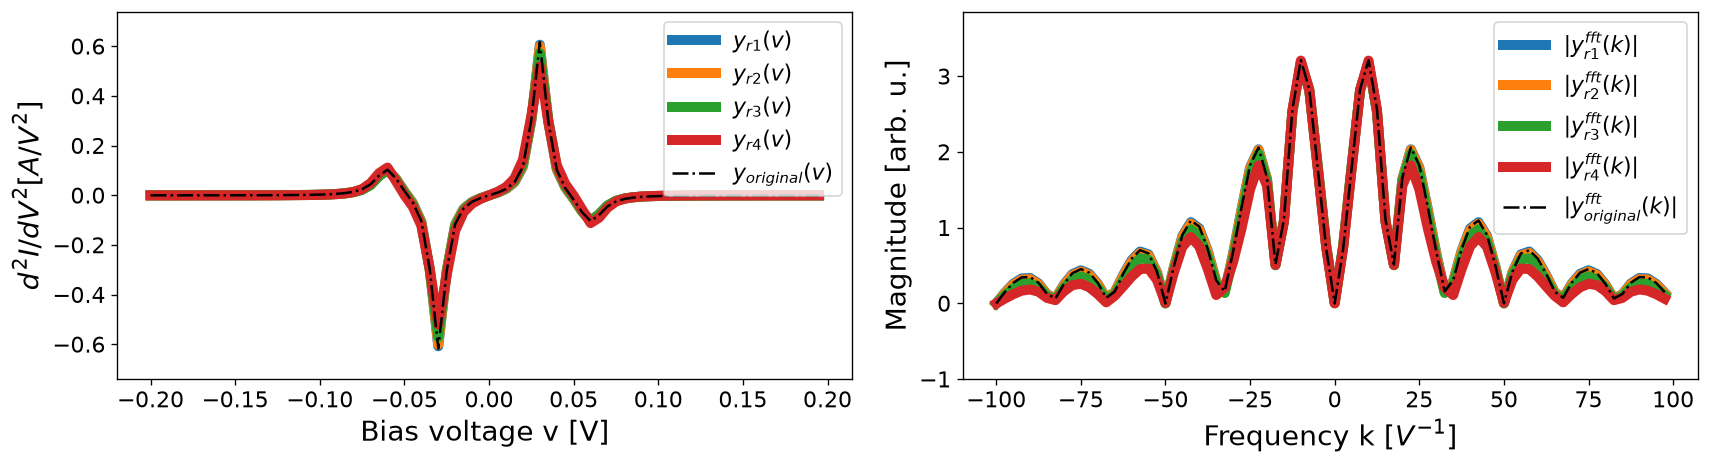

In [33]:
fig3, axs3 = plt.subplots(1, 2, figsize=(17, 9), dpi=120)

axs3[0].plot(x, y_lp21_reconstructed, label="$y_{r1}(v)$", linewidth=6)
axs3[0].plot(x, y_lp22_reconstructed, label="$y_{r2}(v)$", linewidth=6)
axs3[0].plot(x, y_lp23_reconstructed, label="$y_{r3}(v)$", linewidth=6)
axs3[0].plot(x, y_lp24_reconstructed, label="$y_{r4}(v)$", linewidth=6)
axs3[0].plot(x, y_original, "-.", color="k", label="$y_{original}(v)$")

axs3[1].plot(x_fft, abs(y_fft_lp21_hat), label="|$y^{fft}_{r1}(k)$|", linewidth=6)
axs3[1].plot(x_fft, abs(y_fft_lp22_hat), label="|$y^{fft}_{r2}(k)$|", linewidth=6)
axs3[1].plot(x_fft, abs(y_fft_lp23_hat), label="|$y^{fft}_{r3}(k)$|", linewidth=6)
axs3[1].plot(x_fft, abs(y_fft_lp24_hat), label="|$y^{fft}_{r4}(k)$|", linewidth=6)
axs3[1].plot(x_fft, abs(y_fft_original),"-.", color="k", label="|$y^{fft}_{original}(k)$|")

axs3[0].set_xlabel("Bias voltage v [V]", fontsize=font1)
axs3[0].set_ylabel("$d^2I/dV^2 [A/V^2]$", fontsize=font1)
axs3[1].set_xlabel("Frequency k [$V^{-1}$]", fontsize=font1)
axs3[1].set_ylabel("Magnitude [arb. u.]", fontsize=font1)

axs3[0].legend(fontsize=font2, loc="upper right")
axs3[1].legend(fontsize=font2, loc="upper right")

axs3[0].set_ylim([ylim_min, ylim_max])
axs3[1].set_ylim([-1, y_fft_lim_max ])

axs3[0].set_box_aspect(aspect=0.5)
axs3[1].set_box_aspect(aspect=0.5)

axs3[0].tick_params(axis='both', which='major', labelsize=font2)
axs3[1].tick_params(axis='both', which='major', labelsize=font2)

fig3.subplots_adjust(hspace=-0.25, wspace=0.15)

plt.show()

### Reconstructing $y_\text{original}(t)$ from $y_i(t)$:

The addition of noise in the corrupted signals, adds another layer of difficulty. In particular, the algorithm may not be able to resolve all sparse features once the noise level significantly overshadows the contained information. To account for the noise magnitudes in the signals, we need to specify an optional argument in the solver $\lambda$:

In [34]:
if noise_level:
    noise_magnitude1 = np.linalg.norm(noise1)**2
    noise_magnitude2 = np.linalg.norm(noise2)**2
    noise_magnitude3 = np.linalg.norm(noise3)**2
    noise_magnitude4 = np.linalg.norm(noise4)**2
else:
    noise_magnitude = None
y1_reconstructed, y1_sparse_hat  = cssr.Superresolvers(a0, a_tr1, ar1).nlht_lasso(y1, lam=noise_magnitude1)
y2_reconstructed, y2_sparse_hat  = cssr.Superresolvers(a0, a_tr2, ar2).nlht_lasso(y2, lam=noise_magnitude2)
y3_reconstructed, y3_sparse_hat  = cssr.Superresolvers(a0, a_tr3, ar3).nlht_lasso(y3, lam=noise_magnitude3)
y4_reconstructed, y4_sparse_hat  = cssr.Superresolvers(a0, a_tr4, ar4).nlht_lasso(y3, lam=noise_magnitude4)

We have intentionally written a conditional statement for the noise magnitude determination, intended to give room for experimentation with other noise values. ( In particular, **cssr** has a default noise magnitude for lam=None for noiseless signals that mitigates instabilities. )

#### Visualization:

Once again, let us construct the frequency representation of the reconstructed signals:

In [35]:
y1_fft_hat = scipy.fft.fftshift(scipy.fft.fft(y1_reconstructed, axis=0))
y2_fft_hat = scipy.fft.fftshift(scipy.fft.fft(y2_reconstructed, axis=0))
y3_fft_hat = scipy.fft.fftshift(scipy.fft.fft(y3_reconstructed, axis=0))
y4_fft_hat = scipy.fft.fftshift(scipy.fft.fft(y4_reconstructed, axis=0))

As before, the result can be visualized as follows:

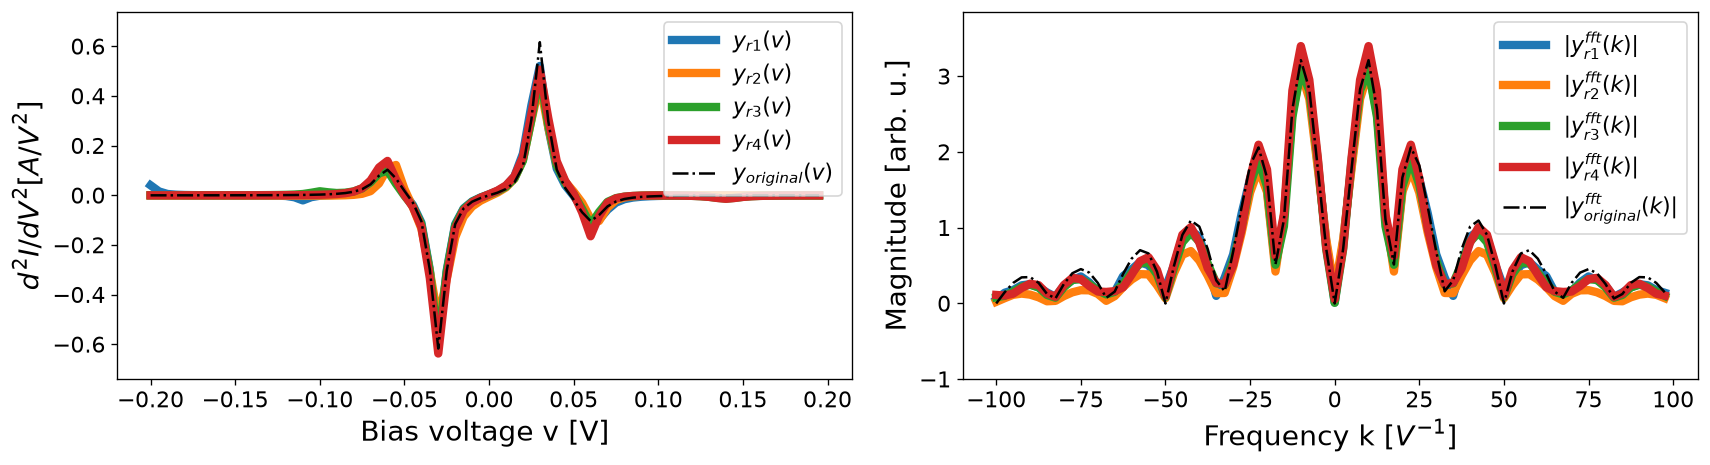

In [36]:
fig4, axs4 = plt.subplots(1, 2, figsize=(17, 9), dpi=120)

axs4[0].plot(x, y1_reconstructed, label="$y_{r1}(v)$", linewidth=5)
axs4[0].plot(x, y2_reconstructed, label="$y_{r2}(v)$", linewidth=5)
axs4[0].plot(x, y3_reconstructed, label="$y_{r3}(v)$", linewidth=5)
axs4[0].plot(x, y4_reconstructed, label="$y_{r4}(v)$", linewidth=5)
axs4[0].plot(x, y_original, "-.", color="k", label="$y_{original}(v)$")

axs4[1].plot(x_fft, abs(y1_fft_hat), label="|$y^{fft}_{r1}(k)$|", linewidth=5)
axs4[1].plot(x_fft, abs(y2_fft_hat), label="|$y^{fft}_{r2}(k)$|", linewidth=5)
axs4[1].plot(x_fft, abs(y3_fft_hat), label="|$y^{fft}_{r3}(k)$|", linewidth=5)
axs4[1].plot(x_fft, abs(y4_fft_hat), label="|$y^{fft}_{r4}(k)$|", linewidth=5)
axs4[1].plot(x_fft, abs(y_fft_original),"-.", color="k", label="|$y^{fft}_{original}(k)$|")

axs4[0].set_xlabel("Bias voltage v [V]", fontsize=font1)
axs4[0].set_ylabel("$d^2I/dV^2 [A/V^2]$", fontsize=font1)
axs4[1].set_xlabel("Frequency k [$V^{-1}$]", fontsize=font1)
axs4[1].set_ylabel("Magnitude [arb. u.]", fontsize=font1)

axs4[0].legend(fontsize=font2, loc="upper right")
axs4[1].legend(fontsize=font2, loc="upper right")

axs4[0].set_ylim([ylim_min, ylim_max])
axs4[1].set_ylim([-1, y_fft_lim_max ])

axs4[0].set_box_aspect(aspect=0.5)
axs4[1].set_box_aspect(aspect=0.5)

axs4[0].tick_params(axis='both', which='major', labelsize=font2)
axs4[1].tick_params(axis='both', which='major', labelsize=font2)

fig4.subplots_adjust(hspace=-0.25, wspace=0.15)

plt.show()

## Summary, conclusion and outlook:

We have seen that physics-imposed resolution limitations can be overcome by applying compressive sensing based methods. In the next tutorial, we will look at the interplay between different frames, the critical frequency, and measurement matrices.